# Modelagem — Comparativo de Variantes da Árvore de Decisão

**Objetivo:** Comparar quatro variantes de `DecisionTreeClassifier` para classificação de gravidade de sinistros (3 classes), todas com `class_weight='balanced'` e avaliadas sobre o mesmo split treino/teste.

| Variante | Restrição | Nota |
|---|---|---|
| DT Irrestrita | nenhuma | árvore completa |
| DT Profundidade 3 | `max_depth=3` | **plotável e interpretável** |
| DT Profundidade 5 | `max_depth=5` | compromisso performance/interpretabilidade |
| DT Podada | `min_samples_leaf=500` | auto-poda via suporte mínimo por folha |

**Métricas:** F1-macro, F1 por classe, AUC-ROC (OvR), matriz de confusão normalizada.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path

from prf_sdk.models.train import (
    compare_decision_trees,
    prepare_features,
    DEFAULT_CONFIGS,
    LEAKAGE_COLS,
    COLS_TO_DROP,
    TARGET_COL,
)
from prf_sdk.models.evaluate import build_comparison_table, plot_decision_tree
from prf_sdk.models.predict import predict, predict_proba

## 1. Carregamento dos dados

In [2]:
BASE_DIR = Path(__name__).resolve().parent.parent

df = pd.read_csv(
    BASE_DIR / "data/processed/datatran_2022_2026_processed_v1.csv",
    index_col=0,
    low_memory=False,
)

print(f"Shape: {df.shape}")
print(f"\nDistribuição da variável-alvo:")
print(df[TARGET_COL].value_counts(normalize=True).map("{:.1%}".format))

Shape: (300086, 45)

Distribuição da variável-alvo:
classificacao_acidente
Com Vítimas Feridas    76.7%
Sem Vítimas            16.1%
Com Vítimas Fatais      7.2%
Name: proportion, dtype: str


## 2. Inspeção das features utilizadas

In [3]:
X, y, feature_names = prepare_features(df)

removed = (LEAKAGE_COLS | COLS_TO_DROP | {TARGET_COL}) & set(df.columns)
print(f"Colunas removidas ({len(removed)}): {sorted(removed)}")
print(f"\nFeatures após one-hot encoding: {X.shape[1]}")
print(f"Registros totais: {X.shape[0]:,}")

Colunas removidas (15): ['causa_acidente', 'classificacao_acidente', 'data_hora', 'feridos', 'feridos_graves', 'feridos_leves', 'ignorados', 'ilesos', 'km', 'latitude', 'longitude', 'mortos', 'municipio', 'pessoas', 'uf']

Features após one-hot encoding: 74
Registros totais: 300,086


## 3. Treinamento comparativo

Features e split treino/teste são computados **uma única vez** e compartilhados entre todas as variantes.

In [4]:
comparisons = compare_decision_trees(df)
print(f"Variantes treinadas: {[c.name for c, _ in comparisons]}")

Variantes treinadas: ['DT Irrestrita', 'DT Profundidade 3', 'DT Profundidade 5', 'DT Podada (min_leaf=500)']


## 4. Tabela comparativa de métricas

In [5]:
table = build_comparison_table(comparisons)

display(
    table.style
    .format({
        "CV F1-macro": "{:.3f}",
        "CV F1-macro dp": "±{:.3f}",
        "CV AUC-ROC": "{:.3f}",
        "CV AUC-ROC dp": "±{:.3f}",
        "Teste F1-macro": "{:.3f}",
        "Teste AUC-ROC": "{:.3f}",
        "F1 Fatais": "{:.3f}",
    })
    .highlight_max(
        subset=["CV F1-macro", "CV AUC-ROC", "Teste F1-macro", "Teste AUC-ROC", "F1 Fatais"],
        props="font-weight: bold; color: #d95f02",
    )
    .highlight_min(
        subset=["CV F1-macro dp", "CV AUC-ROC dp"],
        props="font-weight: bold; color: #1b7837",
    )
)

,CV F1-macro,CV F1-macro dp,CV AUC-ROC,CV AUC-ROC dp,Teste F1-macro,Teste AUC-ROC,F1 Fatais
Modelo,,,,,,,
DT Irrestrita,0.442,±0.004,0.581,±0.003,0.436,0.577,0.195
DT Profundidade 3,0.482,±0.004,0.631,±0.003,0.474,0.624,0.339
DT Profundidade 5,0.440,±0.017,0.672,±0.010,0.424,0.659,0.262
DT Podada (min_leaf=500),0.440,±0.003,0.747,±0.003,0.442,0.746,0.295
Dummy (baseline),0.333,±0.003,0.500,±0.002,0.331,0.498,0.071


## 5. Visualização da Árvore Rasa (Profundidade 3)

A variante `DT Profundidade 3` é a escolhida para visualização: com apenas 3 níveis é possível ler as regras completas de decisão. Os nós são coloridos pela classe majoritária (azul = Sem Vítimas, laranja = Com Feridas, vermelho = Com Fatais).

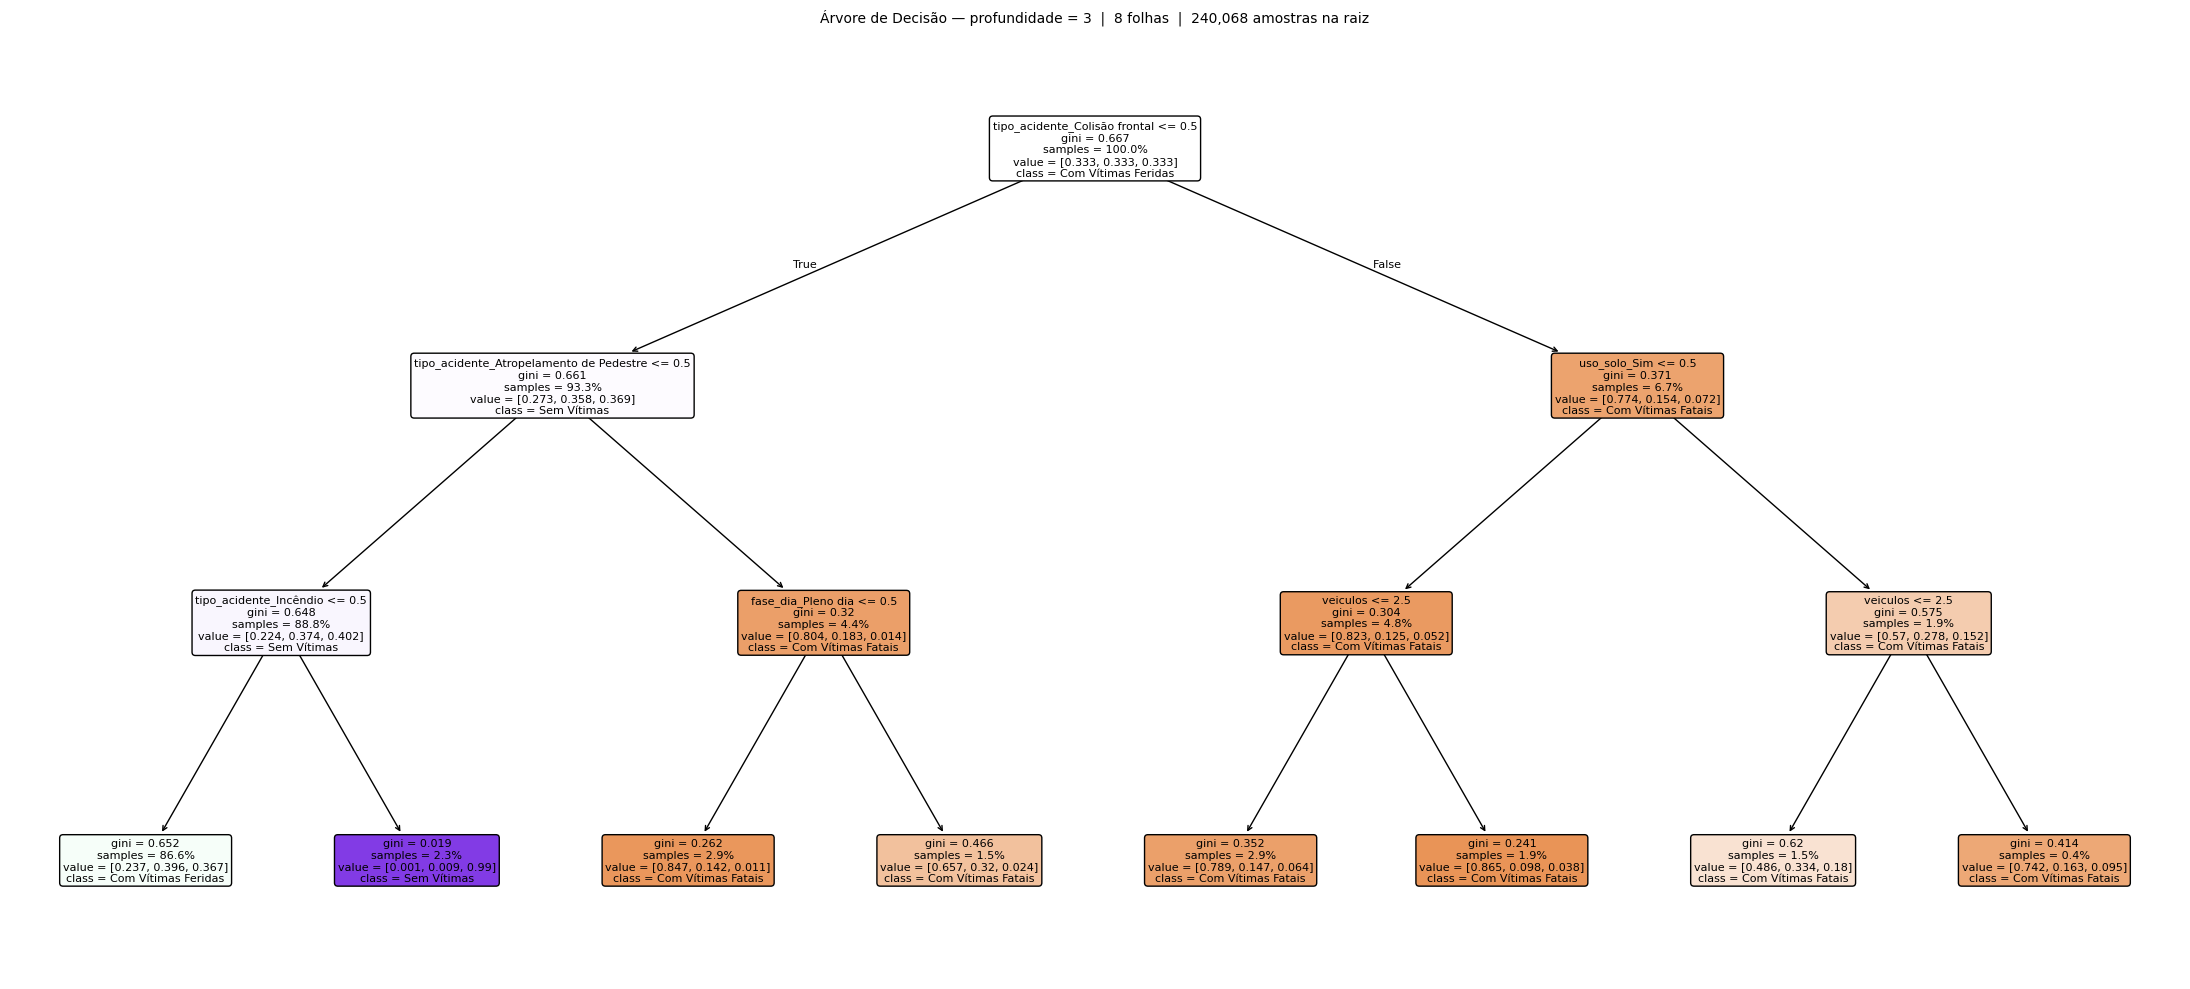


F1-macro (teste): 0.474
F1 Fatais (teste): 0.339


In [6]:
config_shallow, result_shallow = next(
    (c, r) for c, r in comparisons if c.plottable
)

fig, ax = plot_decision_tree(
    result_shallow.model,
    feature_names=result_shallow.X_train.columns.tolist(),
    classes=result_shallow.classes,
)
fig.tight_layout()
#plt.savefig(
#    BASE_DIR / "docs/figures/modelagem_decision_tree_depth3.png",
#    dpi=150,
#    bbox_inches="tight",
#)
plt.show()
print(f"\nF1-macro (teste): {result_shallow.eval_result.f1_macro:.3f}")
print(f"F1 Fatais (teste): {result_shallow.eval_result.f1_per_class['Com Vítimas Fatais']:.3f}")

## 6. Matriz de confusão — todas as variantes

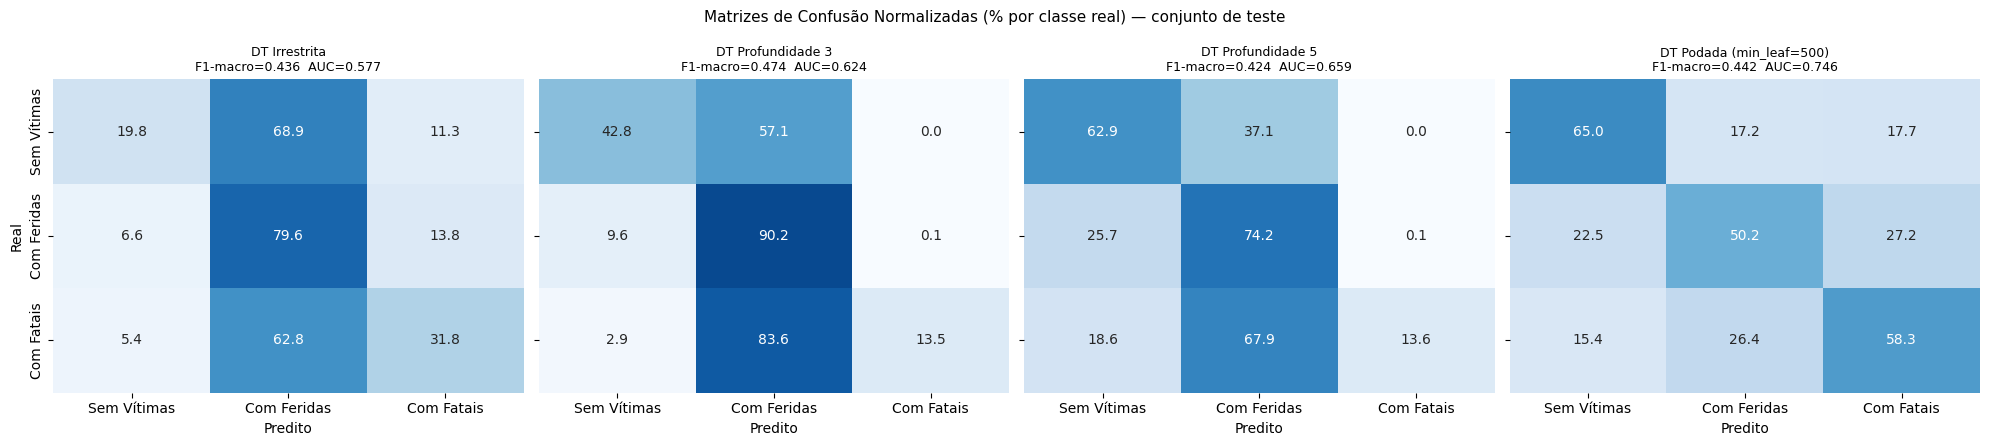

In [7]:
labels_short = ["Sem Vítimas", "Com Feridas", "Com Fatais"]
n = len(comparisons)

fig, axes = plt.subplots(1, n, figsize=(5 * n, 4.5), sharey=True)

for ax, (config, result) in zip(axes, comparisons):
    ev = result.eval_result
    sns.heatmap(
        ev.confusion_matrix * 100,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        xticklabels=labels_short,
        yticklabels=labels_short,
        ax=ax,
        vmin=0,
        vmax=100,
        cbar=False,
    )
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real" if ax is axes[0] else "")
    ax.set_title(
        f"{config.name}\nF1-macro={ev.f1_macro:.3f}  AUC={ev.roc_auc_ovr:.3f}",
        fontsize=9,
    )

fig.suptitle("Matrizes de Confusão Normalizadas (% por classe real) — conjunto de teste", fontsize=11)
fig.tight_layout()
#plt.savefig(
#    BASE_DIR / "docs/figures/modelagem_confusion_matrix.png",
#    dpi=150,
#    bbox_inches="tight",
#)
plt.show()

## 7. Feature Importance — DT Irrestrita vs. DT Profundidade 5

Comparamos as importâncias das duas variantes com melhor performance esperada para verificar consistência.

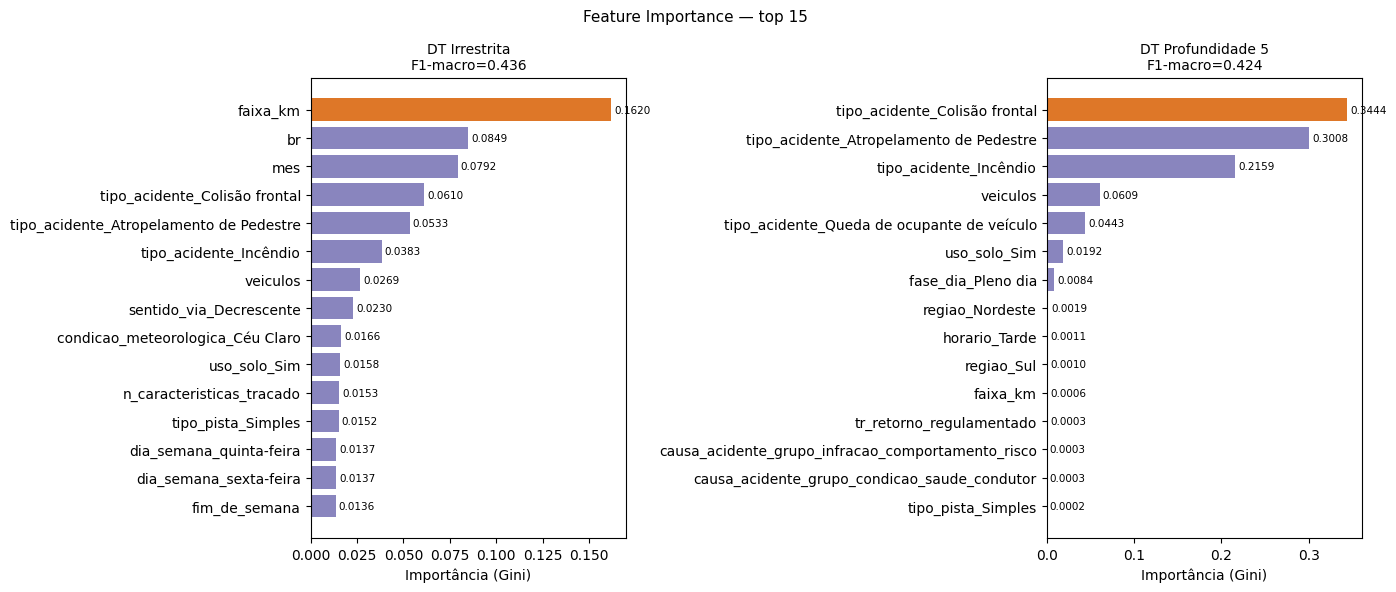

In [8]:
configs_to_plot = [c for c in comparisons if c[0].name in ("DT Irrestrita", "DT Profundidade 5")]

fig, axes = plt.subplots(1, len(configs_to_plot), figsize=(14, 6))

for ax, (config, result) in zip(axes, configs_to_plot):
    fi = result.eval_result.feature_importance
    colors = ["#d95f02" if imp == fi.max() else "#7570b3" for imp in fi.values]
    ax.barh(fi.index[::-1], fi.values[::-1], color=colors[::-1], alpha=0.85)
    for i, (val, name) in enumerate(zip(fi.values[::-1], fi.index[::-1])):
        ax.text(val + fi.max() * 0.01, i, f"{val:.4f}", va="center", fontsize=7.5)
    ax.set_xlabel("Importância (Gini)")
    ax.set_title(
        f"{config.name}\nF1-macro={result.eval_result.f1_macro:.3f}",
        fontsize=10,
    )

fig.suptitle("Feature Importance — top 15", fontsize=11)
fig.tight_layout()
#plt.savefig(
#    BASE_DIR / "docs/figures/modelagem_feature_importance.png",
#    dpi=150,
#    bbox_inches="tight",
#)
plt.show()

## 8. F1 por classe — todas as variantes

In [9]:
_, first_result = comparisons[0]
classes = first_result.classes

f1_rows = []
for config, result in comparisons:
    row = {"Modelo": config.name}
    row.update(result.eval_result.f1_per_class)
    f1_rows.append(row)

dummy_row = {"Modelo": "Dummy (baseline)"}
dummy_row.update(first_result.eval_dummy_result.f1_per_class)
f1_rows.append(dummy_row)

f1_table = pd.DataFrame(f1_rows).set_index("Modelo")
display(
    f1_table.style
    .format("{:.3f}")
    .highlight_max(axis=0, props="font-weight: bold; color: #d95f02")
)

,Com Vítimas Fatais,Com Vítimas Feridas,Sem Vítimas
Modelo,,,
DT Irrestrita,0.195,0.799,0.314
DT Profundidade 3,0.339,0.847,0.237
DT Profundidade 5,0.262,0.773,0.238
DT Podada (min_leaf=500),0.295,0.638,0.394
Dummy (baseline),0.071,0.766,0.156


## 9. Exemplo de predição (DT Profundidade 3)

In [10]:
sample = result_shallow.X_test.head(10)

preds = predict(result_shallow.model, sample)
proba = predict_proba(result_shallow.model, sample)

output = proba.copy()
output.insert(0, "predito", preds)
output.insert(0, "real", result_shallow.y_test.head(10).values)

display(output.style.format({col: "{:.3f}" for col in proba.columns}))

,real,predito,Com Vítimas Fatais,Com Vítimas Feridas,Sem Vítimas
193555,Com Vítimas Feridas,Com Vítimas Feridas,0.237,0.396,0.367
146146,Com Vítimas Feridas,Com Vítimas Feridas,0.237,0.396,0.367
166706,Com Vítimas Feridas,Com Vítimas Feridas,0.237,0.396,0.367
25292,Com Vítimas Feridas,Com Vítimas Feridas,0.237,0.396,0.367
268431,Com Vítimas Feridas,Com Vítimas Fatais,0.657,0.320,0.024
89835,Com Vítimas Feridas,Com Vítimas Feridas,0.237,0.396,0.367
144281,Sem Vítimas,Sem Vítimas,0.001,0.009,0.990
173722,Com Vítimas Fatais,Com Vítimas Fatais,0.789,0.147,0.064
123230,Com Vítimas Feridas,Com Vítimas Feridas,0.237,0.396,0.367
175777,Com Vítimas Feridas,Com Vítimas Fatais,0.847,0.142,0.011


## 10. Resumo final

In [11]:
for config, result in comparisons:
    print("=" * 60)
    print(f"[{config.name}]")
    print(result.summary)
    print()

print("=" * 60)
print(f"Treino: {first_result.X_train.shape[0]:,} registros")
print(f"Teste:  {first_result.X_test.shape[0]:,} registros")
print(f"Features: {first_result.X_train.shape[1]}")

[DT Irrestrita]
Árvore de Decisão — Resultados

Cross-validation (Stratified K-Fold, k=5):
  Classificador  F1-macro = 0.442 ± 0.004  |  AUC-ROC = 0.581 ± 0.003
  Baseline       F1-macro = 0.333 ± 0.003  |  AUC-ROC = 0.500 ± 0.002

Avaliação no conjunto de teste:
  Classificador  F1-macro = 0.436  |  AUC-ROC = 0.577
  Baseline       F1-macro = 0.331  |  AUC-ROC = 0.498

F1 por classe (classificador):
    Com Vítimas Fatais: F1 = 0.195
    Com Vítimas Feridas: F1 = 0.799
    Sem Vítimas: F1 = 0.314

Top-15 features mais importantes:
    faixa_km: 0.1620
    br: 0.0849
    mes: 0.0792
    tipo_acidente_Colisão frontal: 0.0610
    tipo_acidente_Atropelamento de Pedestre: 0.0533
    tipo_acidente_Incêndio: 0.0383
    veiculos: 0.0269
    sentido_via_Decrescente: 0.0230
    condicao_meteorologica_Céu Claro: 0.0166
    uso_solo_Sim: 0.0158
    n_caracteristicas_tracado: 0.0153
    tipo_pista_Simples: 0.0152
    dia_semana_quinta-feira: 0.0137
    dia_semana_sexta-feira: 0.0137
    fim_de_sem